In [1]:
import os
import glob
import datetime

import jax
import numpyro
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hssm
import arviz as az
import seaborn as sns

import sqlite3

jax.config.update('jax_platform_name', 'cpu')
hssm.set_floatX("float32")
numpyro.set_host_device_count(14)

/Users/javierrojas/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Setting PyTensor floatX type to float32.
Setting "jax_enable_x64" to False. If this is not intended, please set `jax` to False.


In [4]:
df_exp = pd.read_csv('hssm_exp4_data.csv')

In [5]:
df_sim = pd.read_csv('hssm_simulated_data.csv')

# plot

In [19]:
def plot_rt_quantiles_participant(
    participant_id,
    real_df,
    sim_df,
    rt_col="rt",
    pid_col="participant_id",
    quantiles=np.linspace(0.1, 0.9, 9)
):
    """
    Plot RT quantile curves for one participant:
    real data vs simulated data.
    """

    # --- standardize dtypes ---
    participant_id = str(participant_id)
    real_df = real_df.copy()
    sim_df = sim_df.copy()

    real_df[pid_col] = real_df[pid_col].astype(str)
    sim_df[pid_col] = sim_df[pid_col].astype(str)

    # --- subset participant ---
    real_p = real_df[real_df[pid_col] == participant_id]
    sim_p  = sim_df[sim_df[pid_col] == participant_id]

    if real_p.empty or sim_p.empty:
        print(f"Participant {participant_id} not found in one of the datasets")
        pass
        #raise ValueError(f"Participant {participant_id} not found in both datasets")

    # --- compute quantiles ---
    real_q = real_p[rt_col].quantile(quantiles).values
    sim_q  = sim_p[rt_col].quantile(quantiles).values

    # --- plot ---
    plt.figure(figsize=(5, 4))
    plt.plot(quantiles, real_q, 'o-', label="Experimental Data")
    plt.plot(quantiles, sim_q,  's--', label="Simulation")

    plt.xlabel("Quantile")
    plt.ylabel("Reaction time (sec)")
    plt.title(f"Participant {participant_id} – RT quantiles")
    plt.legend()
    plt.tight_layout()
    plt.show()

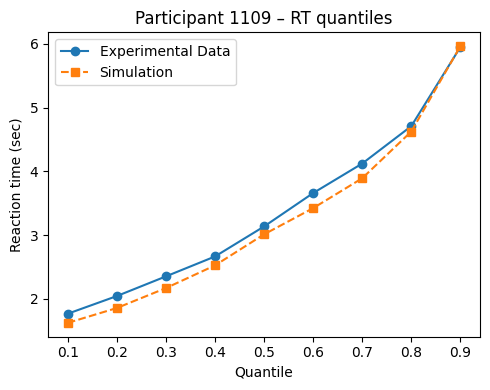

In [20]:
plot_rt_quantiles_participant(1109, df_exp, df_sim)

# 10 random plots

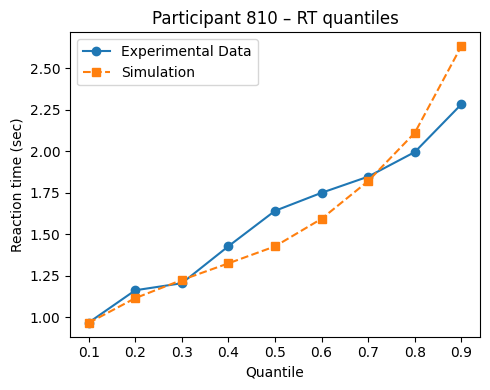

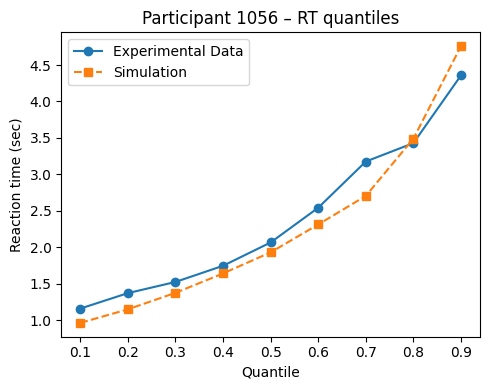

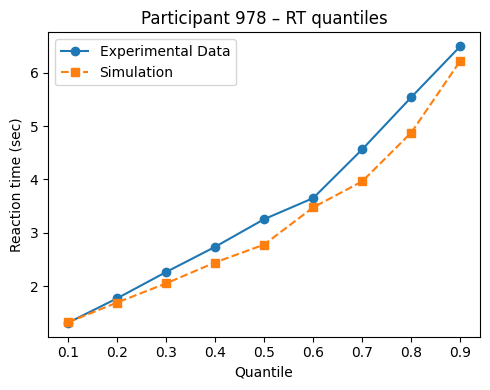

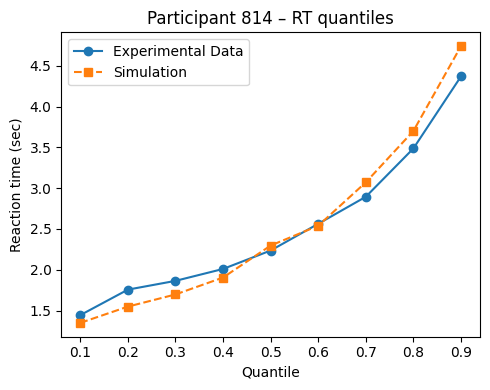

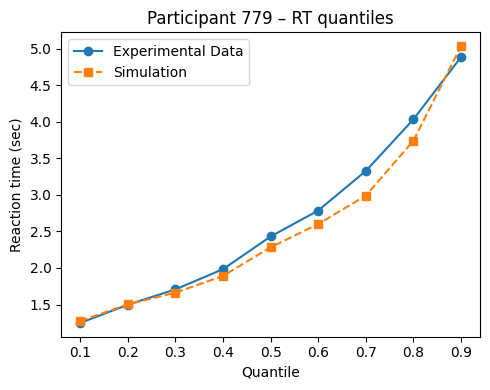

Participant 896 not found in one of the datasets


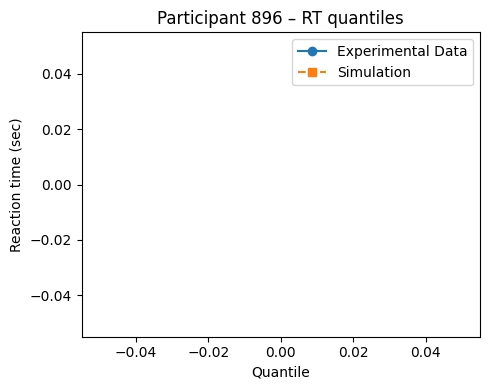

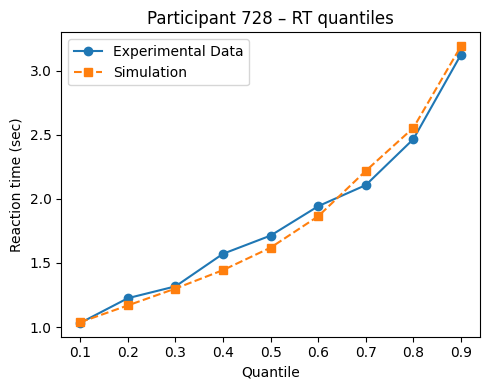

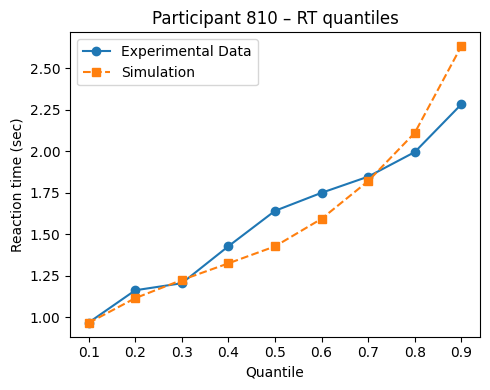

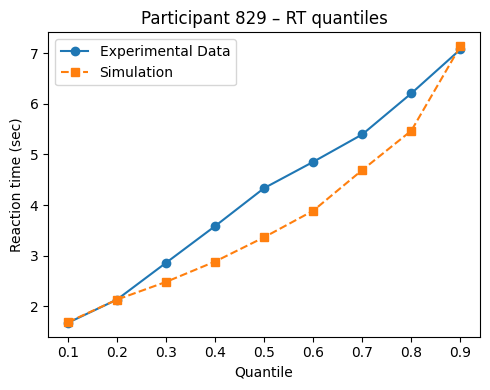

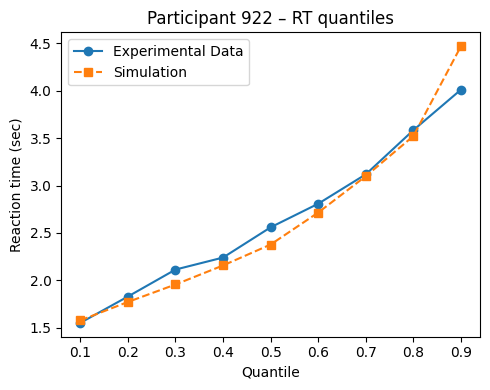

In [21]:
np.random.seed(42)
x = np.random.randint(df_exp['participant_id'].min(), df_exp['participant_id'].max()+1, size=10)
for x in x:
    plot_rt_quantiles_participant(x, df_exp, df_sim)

# Group plot

In [26]:
def plot_rt_quantiles_group(
    real_df,
    sim_df,
    rt_col="rt",
    pid_col="participant_id",
    quantiles=np.linspace(0.1, 0.9, 9),
    show_sem=True
):
    """
    Plot group-average RT quantile curves:
    real data vs simulated data.
    """

    # --- standardize dtypes ---
    real_df = real_df.copy()
    sim_df  = sim_df.copy()

    real_df[pid_col] = real_df[pid_col].astype(str)
    sim_df[pid_col]  = sim_df[pid_col].astype(str)

    # --- helper: participant-level quantiles ---
    def participant_quantiles(df):
        return df[rt_col].quantile(quantiles).values

    # --- real data ---
    real_Q = (
        real_df
        .groupby(pid_col)
        .apply(participant_quantiles)
        .to_list()
    )
    real_Q = np.vstack(real_Q)

    real_mean = real_Q.mean(axis=0)
    real_sem  = real_Q.std(axis=0) / np.sqrt(real_Q.shape[0])

    # --- simulated data ---
    sim_Q = (
        sim_df
        .groupby(pid_col)
        .apply(participant_quantiles)
        .to_list()
    )
    sim_Q = np.vstack(sim_Q)

    sim_mean = sim_Q.mean(axis=0)

    # --- plot ---
    plt.figure(figsize=(5, 4))

    plt.plot(quantiles, real_mean, 'o-', label="Data")
    if show_sem:
        plt.fill_between(
            quantiles,
            real_mean - real_sem,
            real_mean + real_sem,
            alpha=0.3
        )

    plt.plot(quantiles, sim_mean, 's--', label="DDM simulation")

    plt.errorbar(
    quantiles,
    real_mean,
    yerr=real_sem,
    fmt='none',
    capsize=3,
    alpha=0.7
)


    plt.xlabel("Quantile")
    plt.ylabel("Reaction time")
    plt.title("Group-average RT quantiles")
    plt.legend()
    plt.tight_layout()
    plt.show()

/var/folders/65/zt7m7_71489b2xgz9mqdpfl40000gn/T/ipykernel_7996/184005314.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  real_df
/var/folders/65/zt7m7_71489b2xgz9mqdpfl40000gn/T/ipykernel_7996/184005314.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sim_df


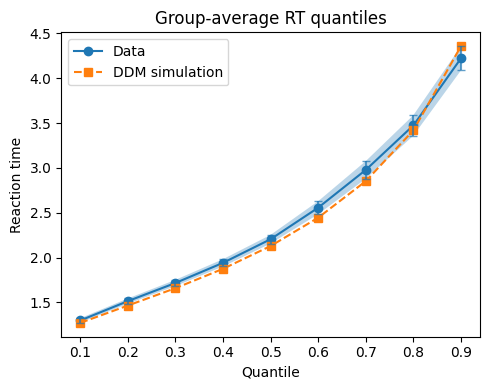

In [27]:
plot_rt_quantiles_group(
    real_df=df_exp,
    sim_df=df_sim
)